# trace geographic history of a single tip across genomic positions

#### import packages

In [2]:
import os

import itertools
from itertools import combinations

import pandas as pd 
import csv 
import numpy as np 

import matplotlib.pyplot as plt 
%matplotlib inline 

import seaborn as sns 

In [3]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [4]:
from Bio import Phylo
#from ete3 import Tree
import json
import seaborn as sns 

In [5]:
import tskit

In [6]:
from Bio import AlignIO

In [7]:
#os.chdir('/home/nahmed/git/bacterial-args/migration/sweep/merge_trees/example')

### import tree sequences

In [8]:
sim = tskit.load("trees/sim_ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15.trees")
inf = tskit.load("trees/inf_ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15.trees")

### import subtrees

In [9]:
sim_subtrees = "subtrees_sim/"
inf_subtrees = "subtrees_inf/" 

### import inferred locations

In [10]:
sim_res = pd.read_csv("sim.states.tsv", sep = "\t")
inf_res = pd.read_csv("inf.states.tsv", sep = "\t")

### import scores

In [11]:
sim_scores = pd.read_csv("scores/sim_ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15.csv")
inf_scores = pd.read_csv("scores/sim_ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15.csv")
ctrl_scores = pd.read_csv("scores/sim_ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15.csv")

### control

In [12]:
ctrl = Phylo.read("results/sim_ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15.nwk", format = "newick") 
ctrl_res = pd.read_csv("locations/control_ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15.csv")

### get locations through time for 1 tip
for true, simulated network, inferred network, and tree

In [13]:
def get_location_from_traits(traits_file): 
    
    with open(traits_file, 'r') as file: 
        data = json.load(file) 
   
    dict = data['nodes']
    subdict = {key: value for (key, value) in dict.items() if 'N' in key}
    subdict = pd.DataFrame(subdict).transpose()
    
    pops = pd.json_normalize(subdict['population_confidence']).set_index(subdict.index)
    res = subdict.join(pops).drop(columns=['population_confidence'])
    res[['1', '2', '3']] = res[['1', '2', '3']].fillna(0)
    res['node'] = res.index
    return res

In [42]:
def trace_tip_tree(newick_path, traits_tsv_path, metadata_tsv_path, alignment_path, target_tip_name):
    # load mapping
    traits = get_location_from_traits(traits_tsv_path)
    meta = pd.read_csv(metadata_tsv_path, sep='\t')
    
    nodedict = dict(zip(traits['node'].astype(str), traits['population'].astype(str)))
    tipdict = dict(zip(meta['strain'].astype(str), meta['population'].astype(str)))
    popdict = nodedict | tipdict
    
    tree = Phylo.read(newick_path, format="newick")
    aln = AlignIO.read(alignment_path, format = "fasta") 
    len_snps = len(aln[0]) 
    rescale_factor = 3000000/len_snps 
    
    # find target tip 
    target_node = None
    for terminal in tree.get_terminals():
        if terminal.name == target_tip_name:
            target_node = terminal
            break
            
    if not target_node:
        raise ValueError(f"Tip '{target_tip_name}' not found in the Newick tree.")
        
    # get path root to tip 
    # fmt [root_child, node_2, ..., target_node]
    path = tree.get_path(target_node)
    lineage_nodes = [tree.root] + path  # Complete ancestral backbone
    
    # get divergence from tip to root (branch length) 
    total_tree_depth = tree.distance(tree.root, target_node)
    
    records = []
    
    # traverse tree tip to root 
    for node in reversed(lineage_nodes):
        # calculate time (total depth - distance from root) 
        distance_from_root = tree.distance(tree.root, node)
        node_time = total_tree_depth - distance_from_root
        node_time_rescale = node_time / (rescale_factor) 
        
        # get location 
        location = popdict.get(str(node.name), None) if node.name else None
        
        records.append({
            # 'type':'tree',
            # 'tip': target_tip_name,
            # 'time': node_time/2.500e-8,
            # 'position': 0,        
            # 'tree_index': 0,     
            # 'location': str(int(location)-1)

            'type': 'tree', 
            'tip': target_tip_name,
            'time': node_time_rescale/2.500e-8,
            'tree_index': 0,
            'left': 0,    
            'right': 3e6, 
            'location': str(int(location)-1)
        })
        
    return pd.DataFrame(records)


In [43]:
def trace_tip_full_ts(tree_sequence_path, states_tsv_path, target_tip):
    ts = tskit.load(tree_sequence_path)
    
    # Load and index states: (tree_index, node_id) -> location string
    states_df = pd.read_csv(states_tsv_path, sep='\t')
    states_df['NODE_NAME'] = states_df['NODE_NAME'].astype(int)
    states_df['TREE_INDEX'] = states_df['TREE_INDEX'].astype(int)
    state_map = states_df.set_index(['TREE_INDEX', 'NODE_NAME'])['STATE'].to_dict()
    
    records = []
    num_trees = ts.num_trees

    # Loop over every tree, skipping the first (index 0) and last (num_trees - 1)
    for tree in ts.trees():
        tree_idx = tree.index
        
        # Skip boundary trees
        if tree_idx == 0 or tree_idx == num_trees - 1:
            continue
            
        # Traverse from the target tip up to the root
        current_node = target_tip
        while current_node != tskit.NULL:
            node_time = ts.node(current_node).time
            location = state_map.get((tree_idx, current_node), None)
            
            records.append({
                'type': 'network', 
                'tip': target_tip,
                'time': node_time,
                'tree_index': tree_idx,
                'left': tree.interval.left,    # True genomic start of this tree
                'right': tree.interval.right,  # True genomic end of this tree
                'location': location
            })
            
            # Step up to the ancestral parent node
            current_node = tree.parent(current_node)
            
    return pd.DataFrame(records)

In [44]:
tree_res = trace_tip_tree(newick_path = "rerun/results/sim_ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15.nwk", 
                          traits_tsv_path = "rerun/results/sim_ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15_traits.json", 
                          metadata_tsv_path = "rerun/metadata/sim_ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15.tsv",
                          alignment_path = "rerun/sim_ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15.filtered_polymorphic_sites.fasta",
                          target_tip_name = '18')

In [45]:
test_res = trace_tip_full_ts(tree_sequence_path = "trees/inf_ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15.trees",
             states_tsv_path = "inf.states.tsv", 
             target_tip = 18)

In [46]:
merged = pd.concat([test_res, tree_res])

## plot

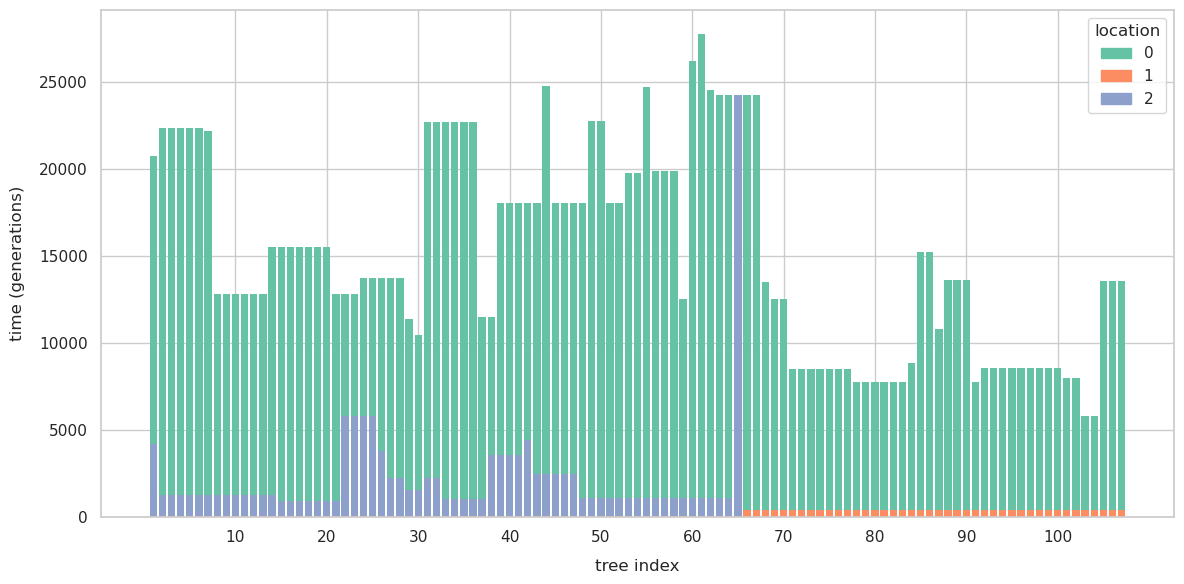

In [47]:
# sort df 
df_sorted = test_res.sort_values(by=['type', 'tree_index', 'time']).copy()

# duration = parent node time - current node time
df_sorted['duration'] = df_sorted.groupby(['type', 'tree_index'])['time'].diff().shift(-1)

# remove NA durations (root) 
df_plot = df_sorted.dropna(subset=['duration']).copy()

# color map
colors = sns.color_palette("Set2", len([0,1,2]))
color_map = {loc: color for loc, color in zip([0,1,2], colors)}


plot_df = df_plot.copy()

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
ax = plt.gca()

# color::location
unique_locations = sorted(plot_df['location'].dropna().unique())
colors = sns.color_palette("Set2", len(unique_locations))
color_map = dict(zip(unique_locations, colors))

tracked_labels = set()

# loop through and plot for each index 
for tree_idx, group in plot_df.groupby('tree_index'):
    # height baseline 
    current_bottom = 0.0
    
    for _, row in group.iterrows():
        loc = row['location']
        height = row['duration']
        
        label = loc if loc not in tracked_labels else "_"
        tracked_labels.add(loc)
        
        # draw bar
        ax.bar(
            x=tree_idx,
            height=height,
            bottom=current_bottom,
            width=0.8,              # Clean bar spacing width
            color=color_map.get(loc, 'gray'),
            edgecolor='none',
            label=label
        )
        
        current_bottom += height


plt.xlabel("tree index", fontsize=12, labelpad=10)
plt.ylabel("time (generations)", fontsize=12, labelpad=10)

# labs
all_trees = sorted(plot_df['tree_index'].unique())
plt.xticks(all_trees[9::10])

# legend
# plt.legend(title="location", loc="upper right", frameon=True)

legend_handles = [ plt.Rectangle((0, 0), 1, 1, color=color_map.get(loc, 'gray')) for loc in [0,1,2] ]

plt.legend(
    handles=legend_handles, 
    labels=[0,1,2], 
    title="location", 
    loc="upper right", 
    frameon=True
)

plt.tight_layout()
plt.show()


In [48]:
# sort df 
df_sorted = merged.sort_values(by=['type', 'tree_index', 'time']).copy()

# duration = parent node time - current node time
df_sorted['duration'] = df_sorted.groupby(['type', 'tree_index'])['time'].diff().shift(-1)

# remove NA durations (root) 
df_plot = df_sorted.dropna(subset=['duration']).copy()

In [49]:
plot_df[plot_df['time']==0]

,type,tip,time,tree_index,left,right,location,duration
0,network,18,0.0,1,245.0,181808.0,1,2.349848
9,network,18,0.0,2,181808.0,191622.0,1,2.349848
18,network,18,0.0,3,191622.0,208254.0,1,2.349848
26,network,18,0.0,4,208254.0,219031.0,1,2.349848
34,network,18,0.0,5,219031.0,257289.0,1,2.349848
...,...,...,...,...,...,...,...,...
741,network,18,0.0,103,2956943.0,2965891.0,1,2.349848
748,network,18,0.0,104,2965891.0,2978155.0,1,2.349848
756,network,18,0.0,105,2978155.0,2990643.0,1,2.349848
763,network,18,0.0,106,2990643.0,2997184.0,1,2.349848


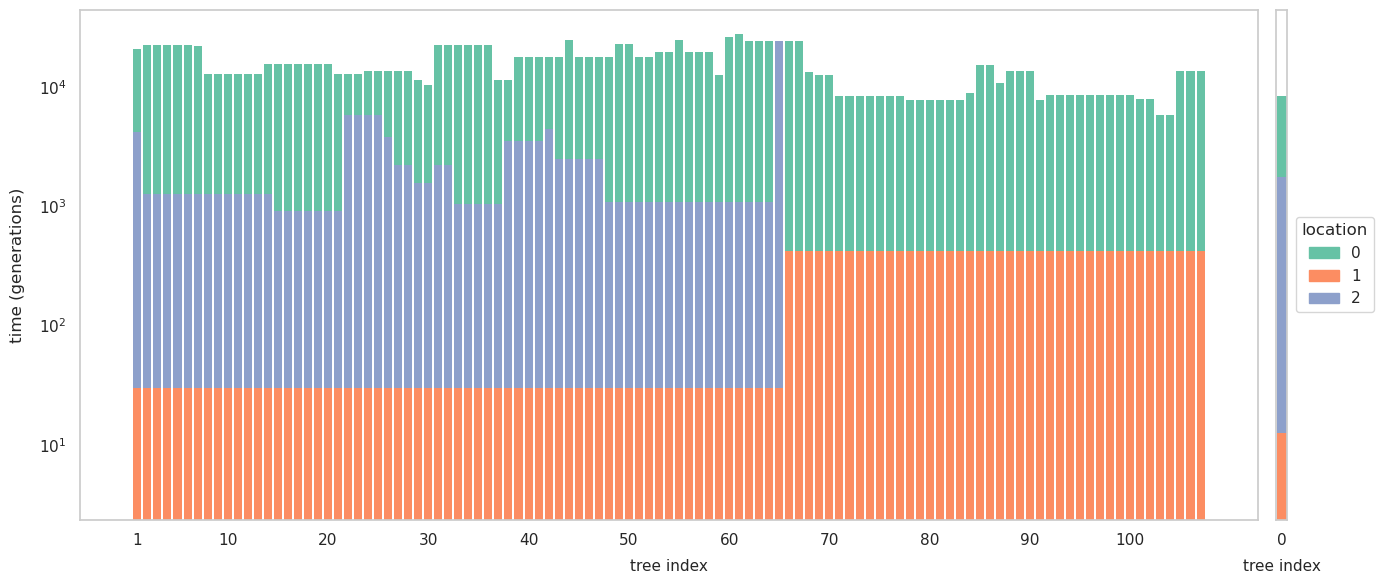

In [54]:
plot_df = df_plot.copy()
plot_df['location'] = plot_df['location'].astype(int)

# color mapping
CUSTOM_LOCATIONS = [0, 1, 2]
colors = sns.color_palette("Set2", len(CUSTOM_LOCATIONS))
color_map = {loc: color for loc, color in zip(CUSTOM_LOCATIONS, colors)}

unique_types = sorted(plot_df['type'].unique())

# width ratio bc control has width = 1 index 
width_ratios = []
for r_type in unique_types:
    num_unique_trees = plot_df[plot_df['type'] == r_type]['tree_index'].nunique()
    width_ratios.append(max(1, num_unique_trees))


sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(
    nrows=1, 
    ncols=len(unique_types), 
    figsize=(14, 6), 
    sharey=True,
    gridspec_kw={'width_ratios': width_ratios} # dynamic subplot width
)

# loop through types
for ax, r_type in zip(axes, unique_types):
    type_data = plot_df[plot_df['type'] == r_type]
    
    for tree_idx, group in type_data.groupby('tree_index'):
        current_bottom = 0.0
        
        for _, row in group.iterrows():
            loc = row['location']
            height = row['duration']
            
            ax.bar(
                x=tree_idx,
                height=height,
                bottom=current_bottom,
                width=0.8,
                color=color_map.get(loc, 'gray'),
                edgecolor='none'
            )
            current_bottom += height
            
    
    ax.set_xlabel("tree index", fontsize=11, labelpad=8)
    ax.grid(False)
    ax.set_yscale("log")
    
    
    all_trees = sorted(type_data['tree_index'].unique())
    if len(all_trees) <= 3:
        
        ax.set_xticks(all_trees)
    else:
        
        custom_ticks = [all_trees[0]] + all_trees[9::10]
        ax.set_xticks(custom_ticks)

axes[0].set_ylabel("time (generations)", fontsize=12, labelpad=10)

# legend
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_map.get(loc, 'gray')) 
    for loc in CUSTOM_LOCATIONS
]

plt.legend(
    handles=legend_handles, 
    labels=CUSTOM_LOCATIONS, 
    title="location", 
    loc="center left", 
    bbox_to_anchor=(1.05, 0.5), 
    frameon=True
)

plt.tight_layout()
plt.show()


In [51]:
# def tip_locations_sim()
# def tip_locations_inf()
# def tip_locations_ctrl()

#### theme

In [52]:
location_colors = {"0" : "red", 
                   "1" : "green", 
                   "2" : "blue" } 

In [53]:
# y = time 
# x = position 
# color = location 